# 01 - Imports

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('whitegrid')

RSEED = 42

In [155]:
df = pd.read_csv('./../Data/Train.csv')
df.head(2)


,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.0,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.6,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652


# 02 - EDA

In [156]:
df.describe()

,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
count,30557.000000,30557.000000,30557.000000,3.055700e+04,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,...,23320.000000,23320.000000,23320.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000
mean,61.148045,29.025866,117.992234,7.983756e+03,125.831135,15.302326,70.552747,0.006004,9.321342,0.416886,...,35.590916,-123.697777,46.533951,923.231949,1711.793613,0.016227,1.254703,13.849040,-69.098594,23.100630
std,46.861309,33.119775,100.417713,4.863090e+04,146.581856,10.688573,18.807884,0.003787,9.343226,2.707990,...,18.955228,71.916036,14.594267,929.633988,1741.299304,0.027016,55.101250,18.004375,84.702355,24.786350
min,1.000000,1.000000,1.000000,0.000000e+00,2.000000,0.420044,5.128572,0.000139,-34.647879,-15.559646,...,0.000000,-179.880630,0.000000,0.000000,0.000000,0.000000,-105.367363,0.000000,-179.947422,0.000000
25%,25.000000,5.000000,60.000000,1.064920e+03,44.000000,7.666667,58.600002,0.003403,3.123071,-1.097864,...,19.451524,-165.882624,36.693094,0.000000,0.000000,0.000000,0.000000,0.000000,-161.726937,0.000000
50%,50.000000,15.000000,91.000000,2.395350e+03,72.000000,12.200000,74.099998,0.004912,8.478424,0.222092,...,37.918838,-156.637162,47.445010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,44.000000,155.000000,5.882550e+03,150.000000,19.900000,85.450001,0.007562,16.201563,1.772925,...,52.270055,-118.453598,57.438181,1861.674119,3393.541633,0.023829,62.245728,27.412303,0.000000,47.090635
max,815.000000,438.000000,999.000000,1.841490e+06,1552.000000,72.599998,100.000000,0.021615,37.437921,17.955124,...,66.111289,179.776125,79.631711,2112.522949,6478.550544,0.210483,77.355232,59.972710,179.813344,69.992363


## Missing values

<Axes: >

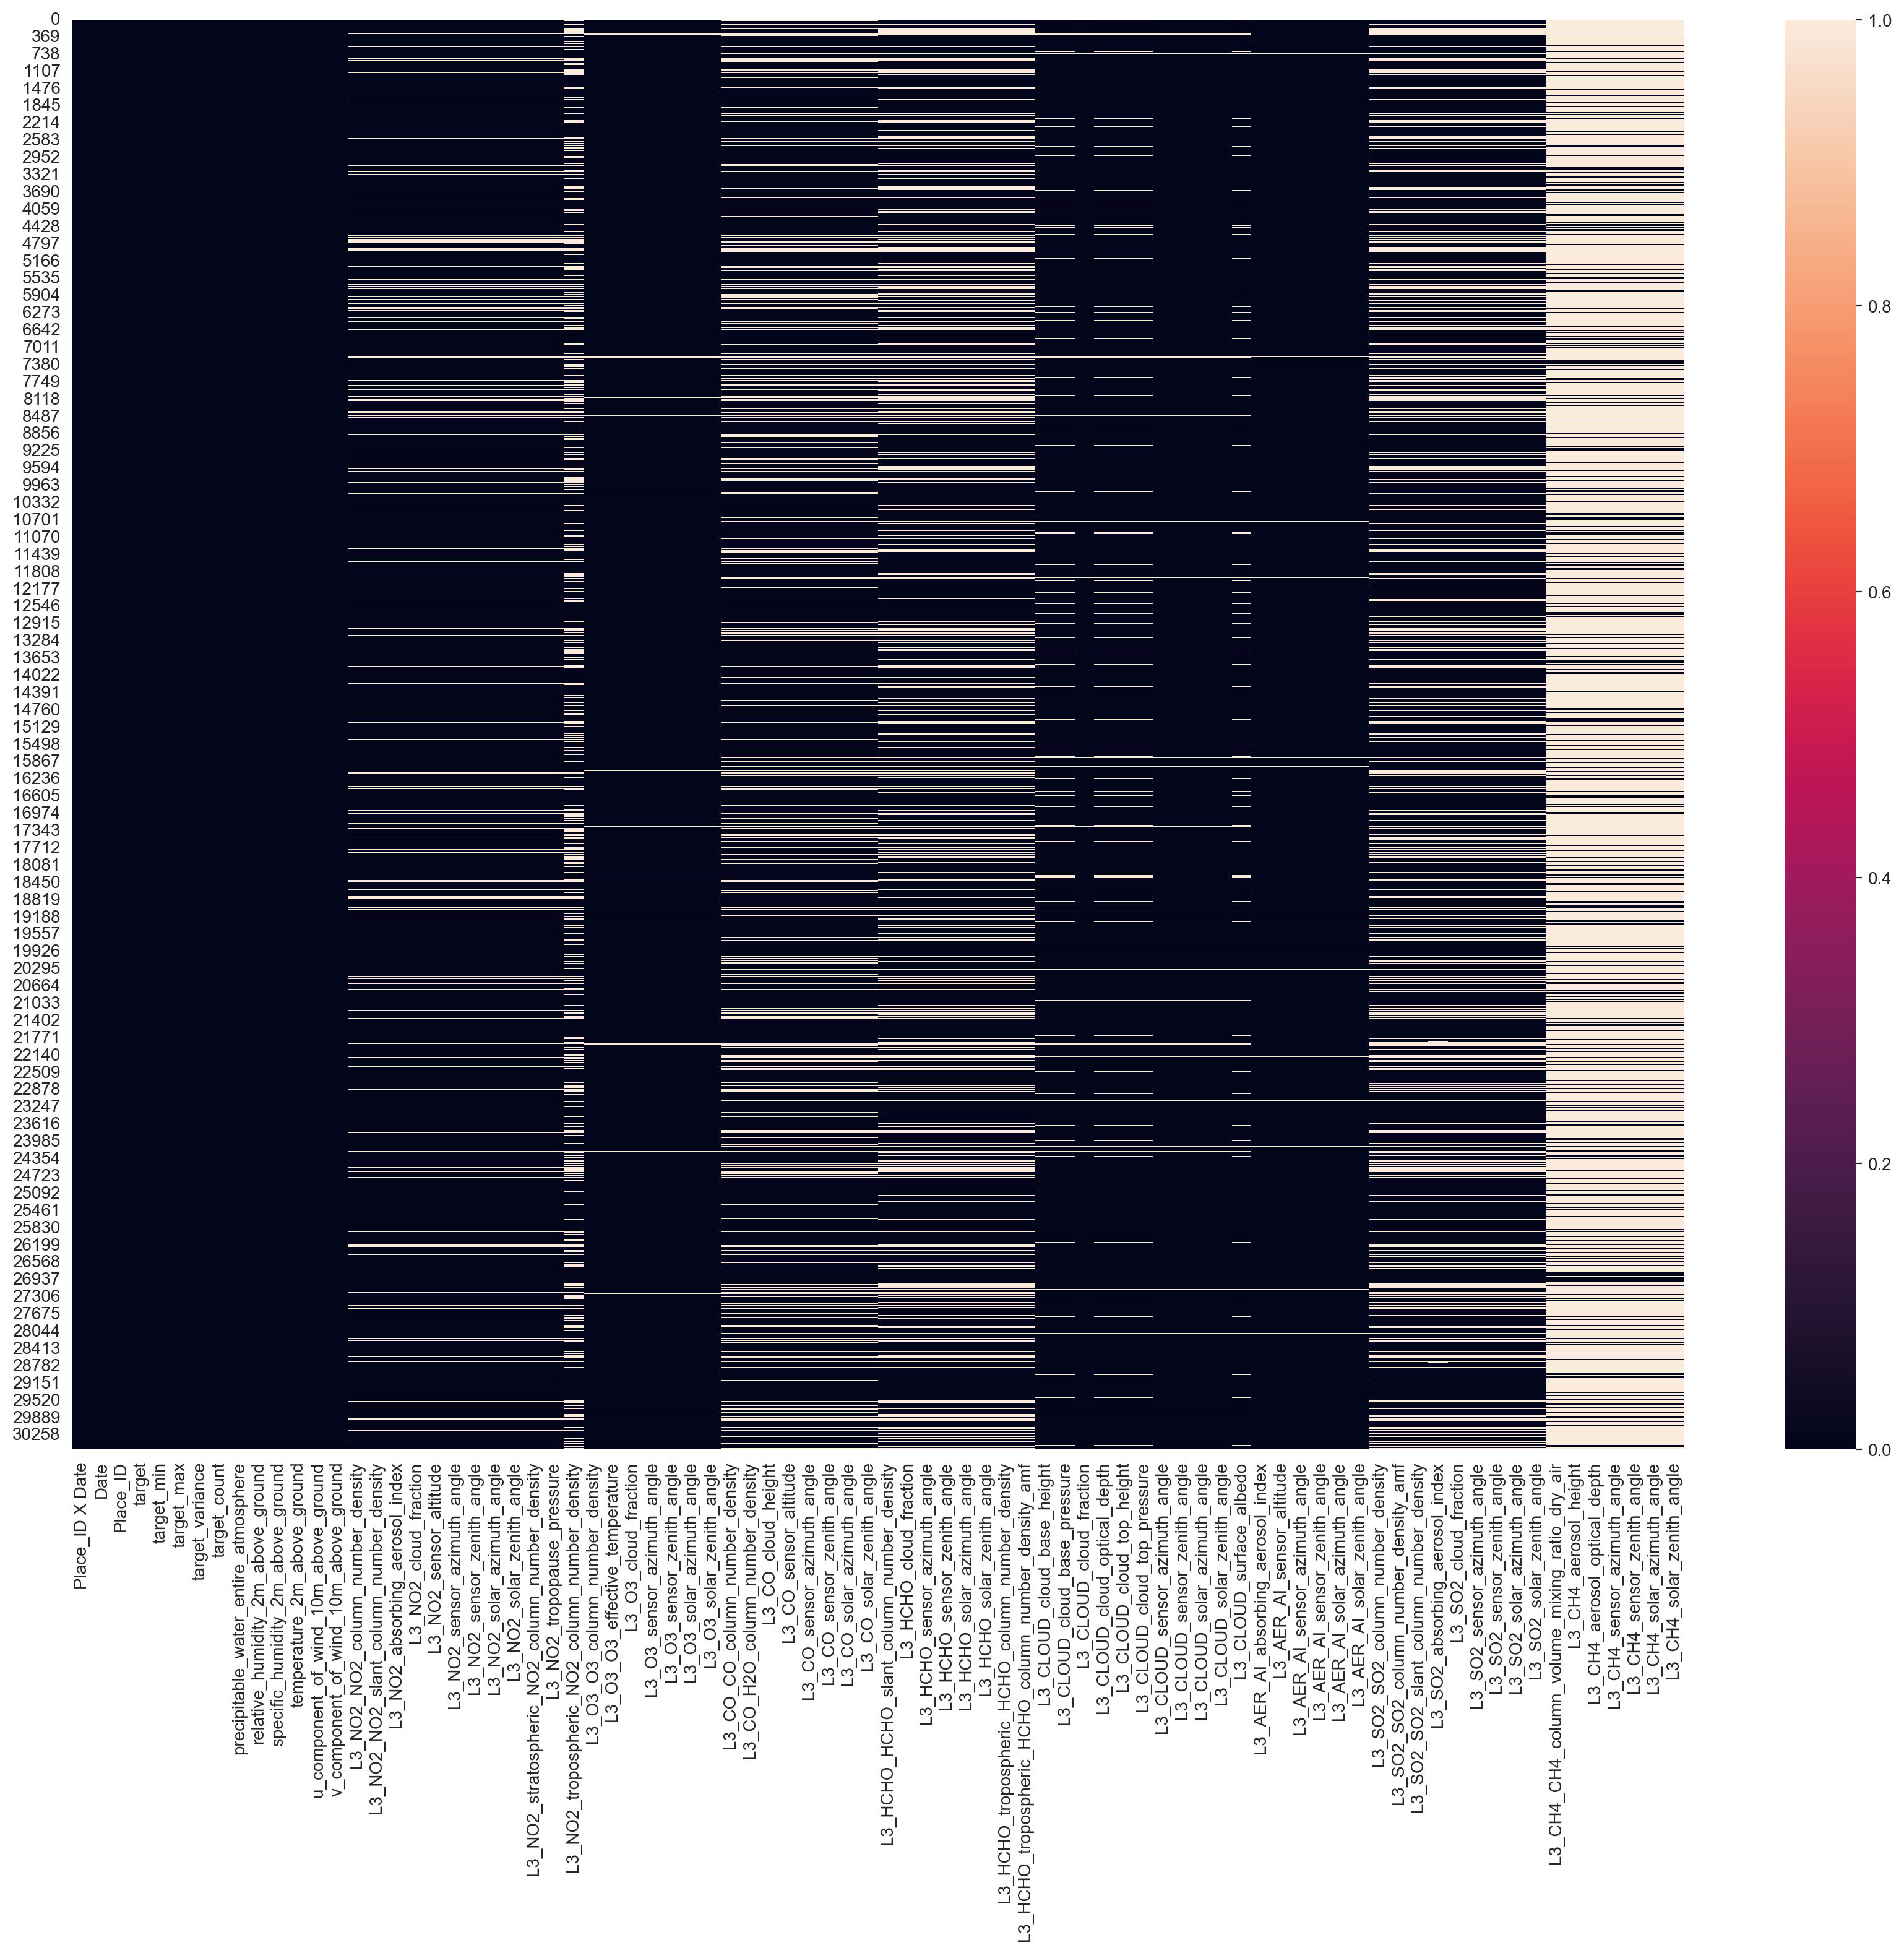

In [157]:
plt.figure(figsize=(21,15), dpi=200)
sns.heatmap(df.isna())

In [158]:
missing_val_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().mean() * 100).round(2)
})

print(missing_val_summary.sort_values(by='Percentage (%)', ascending=False))



                                      Missing Count  Percentage (%)
L3_CH4_solar_zenith_angle                     24765           81.05
L3_CH4_solar_azimuth_angle                    24765           81.05
L3_CH4_sensor_zenith_angle                    24765           81.05
L3_CH4_sensor_azimuth_angle                   24765           81.05
L3_CH4_aerosol_optical_depth                  24765           81.05
...                                             ...             ...
u_component_of_wind_10m_above_ground              0            0.00
temperature_2m_above_ground                       0            0.00
specific_humidity_2m_above_ground                 0            0.00
relative_humidity_2m_above_ground                 0            0.00
Place_ID X Date                                   0            0.00

[82 rows x 2 columns]


The L3_CH4 columns contain a lot of missing values with up to 81% and will get dropped as a result
 

### Columns to drop definition

In [159]:
ch4_cols = [col for col in df.columns if col.startswith('L3_CH4')]
ch4_cols

['L3_CH4_CH4_column_volume_mixing_ratio_dry_air',
 'L3_CH4_aerosol_height',
 'L3_CH4_aerosol_optical_depth',
 'L3_CH4_sensor_azimuth_angle',
 'L3_CH4_sensor_zenith_angle',
 'L3_CH4_solar_azimuth_angle',
 'L3_CH4_solar_zenith_angle']

## Dropping columns

In [160]:
df.drop(ch4_cols, axis= 1, errors='ignore', inplace= True )

## Imputing values


### Replacing 0.0 values with nan



In [161]:
# suspicious_zero_cols = [col for col in df.columns if 'density' in col or 'angle' in col or 'altitude' in col or 'pressure' in col]


# for col in suspicious_zero_cols:
#     # We check if the count of zeros is high or if it's a critical column
#     num_zeros = (df[col] == 0).sum()
#     if num_zeros > 0:
#         print(f"Replacing {num_zeros} zeros in {col}")
#         df[col] = df[col].replace(0, np.nan)

In [162]:
df.replace(0.0, np.nan, inplace=True)

### interpolate the nan values 

In [163]:
df = df.groupby('Place_ID',as_index=False).apply(lambda x: x.interpolate(limit_direction='both'))


In [164]:
df.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30557 entries, (0, 0) to (339, 30556)
Data columns (total 75 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 3

still some of the columns have missing values, this might be due to some places having very little datapoints so they cant be imputed



In [165]:
df['Place_ID'].value_counts(ascending=True)

Place_ID
5IUK9TG     3
MJSB8K5     7
6KAHP8X    12
S91MBTB    29
LKE9VQB    41
           ..
1PRBF5P    94
H6JSAYZ    94
H7QOMTD    94
HN3YMTM    94
010Q650    94
Name: count, Length: 340, dtype: int64

In [166]:
df = df.groupby('Place_ID', as_index=False).filter(lambda x: len(x) >= 40)


In [167]:
df.isnull().sum()

Place_ID X Date                0
Date                           0
Place_ID                       0
target                         0
target_min                     0
                              ..
L3_SO2_cloud_fraction          0
L3_SO2_sensor_azimuth_angle    0
L3_SO2_sensor_zenith_angle     0
L3_SO2_solar_azimuth_angle     0
L3_SO2_solar_zenith_angle      0
Length: 75, dtype: int64

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (339, 30556)
Data columns (total 75 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30506 non-null  object 
 1   Date                                                 30506 non-null  object 
 2   Place_ID                                             30506 non-null  object 
 3   target                                               30506 non-null  float64
 4   target_min                                           30506 non-null  float64
 5   target_max                                           30506 non-null  float64
 6   target_variance                                      30506 non-null  float64
 7   target_count                                         30506 non-null  int64  
 8   precipitable_water_entire_atmosphere                 3

# 03 Feature Engineering

* combine the angles
* AMF for NO2, SO2 and Formaldehyde
* atmospheric ratios for NO2 and cloud


In [169]:
df.columns


Index(['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min',
       'target_max', 'target_variance', 'target_count',
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
   

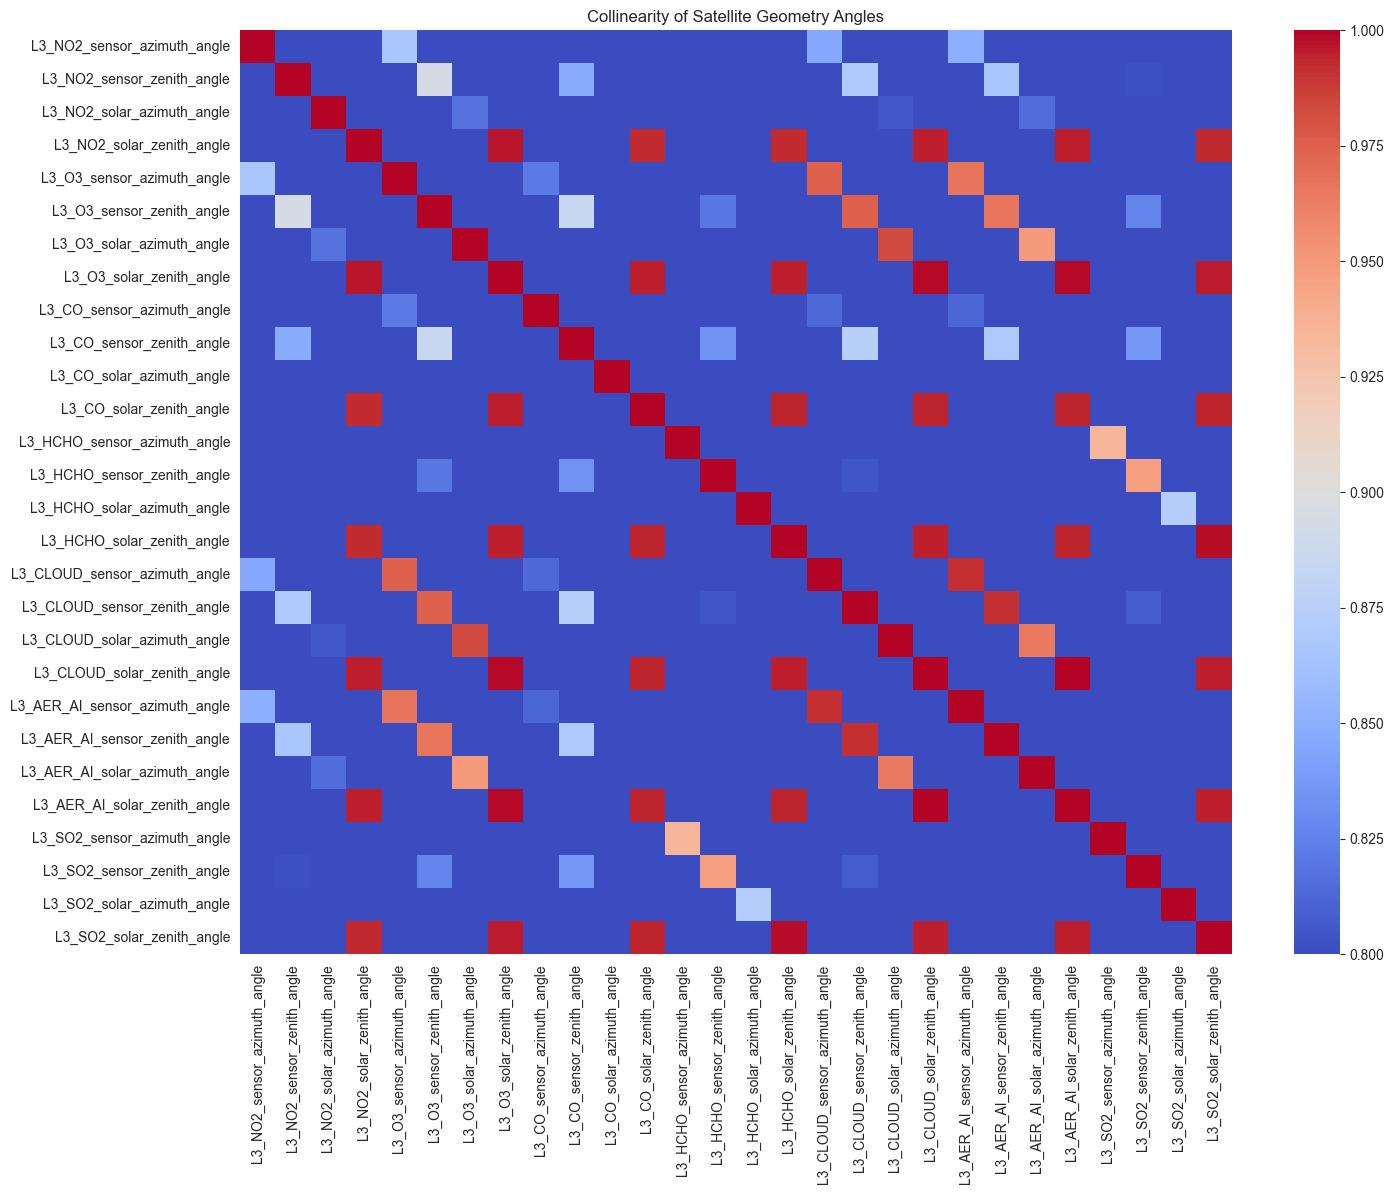

In [170]:


import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter only columns containing 'angle'
angle_cols = [c for c in df.columns if 'angle' in c]

# 2. Calculate the Correlation Matrix
corr_matrix = df[angle_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False,      # Set to True if you want to see the 0.99 numbers
            cmap='coolwarm',  # Red is high correlation, Blue is low
            vmin=0.8, vmax=1) # Zoom in on high correlation to see detail
            
plt.title("Collinearity of Satellite Geometry Angles")
plt.show()

In [171]:
angle_cols = [c for c in df.columns if 'sensor_azimuth' in c]
df[angle_cols]

L3_NO2_sensor_azimuth_angle  L3_O3_sensor_azimuth_angle   
0   0                        76.537512                   76.536426  \
    1                       -14.708036                  -14.708036   
    2                      -105.201338                 -105.201338   
    3                      -104.334056                 -104.334066   
    4                        58.850179                   58.850179   
...                                ...                         ...   
339 30552                   -16.856890                  -16.856890   
    30553                   -52.308049                  -85.223618   
    30554                  -103.669725                 -103.669725   
    30555                    71.096634                   71.095058   
    30556                    71.096634                   71.095058   

           L3_CO_sensor_azimuth_angle  L3_HCHO_sensor_azimuth_angle   
0   0                       74.543393                     76.536426  \
    1                      -57.015200                    -14.708036   
    2                     -103.494458                   -105.201338   
    3                     -101.955931                   -104.334066   
    4                       15.499573                     58.850179   
...                               ...                           ...   
339 30552                  -19.340150                    -16.856890   
    30553                  -96.087323                    -85.223618   
    30554                  -96.527250                   -103.669725   
    30555                   67.455638                     71.099259   
    30556                   67.455638                     71.099259   

           L3_CLOUD_sensor_azimuth_angle  L3_AER_AI_sensor_azimuth_angle   
0   0                          76.536426                       76.537512  \
    1                         -14.708036                      -14.708036   
    2                        -105.201338                     -105.201338   
    3                        -104.334066                     -104.334056   
    4                          58.850179                       58.850179   
...                                  ...                             ...   
339 30552                     -16.856890                      -16.856890   
    30553                     -85.223618                      -23.953088   
    30554                    -103.669725                     -103.669725   
    30555                      71.095058                       71.094890   
    30556                      71.095058                       71.094890   

           L3_SO2_sensor_azimuth_angle  
0   0                        76.536426  
    1                       -14.708036  
    2                      -105.201338  
    3                      -104.334066  
    4                        58.850179  
...                                ...  
339 30552                   -16.856890  
    30553                   -85.223618  
    30554                  -103.669725  
    30555                    71.095910  
    30556                    71.095910  

[30506 rows x 7 columns]

In [172]:
def relative_mean_angles(df: pd.DataFrame):
    angle_map = {
        'solar_azimuth': [col for col in df.columns if 'solar_azimuth_angle' in col],
        'sensor_azimuth': [col for col in df.columns if 'sensor_azimuth_angle' in col],
        'solar_zenith': [col for col in df.columns if 'solar_zenith_angle' in col],
        'sensor_zenith': [col for col in df.columns if 'sensor_zenith_angle' in col]
    }

    mean_var = pd.DataFrame()
    for name, cols in angle_map.items():
        mean_var[f'mean_{name}'] = df[cols].mean(axis=1)

    df['relative_azimuth'] = np.abs(mean_var['mean_solar_azimuth'] - mean_var['mean_sensor_azimuth'])


    df['relative_zenith'] = np.abs(mean_var['mean_solar_zenith'] - mean_var['mean_sensor_zenith'])

    # Calculate Air Mass Factor Proxy (1 / cos(solar_zenith))
    # This is physically significant for light path length through the atmosphere
    #df['solar_zenith_rad'] = np.radians(df['mean_solar_zenith'])
    #df['air_mass_factor_proxy'] = 1 / np.cos(df['solar_zenith_rad'])

    # 5. Clean up: Remove all the original redundant angle columns
    all_original_angles = [col for list_of_cols in angle_map.values() for col in list_of_cols]
    df.drop(columns=all_original_angles, inplace=True)
    #df.drop(columns=all_original_angles + ['solar_zenith_rad'], inplace=True)

    print(f"Reduced features. New columns added: {list(df.columns[-6:])}")
    return df

df = relative_mean_angles(df)

Reduced features. New columns added: ['L3_SO2_SO2_column_number_density_amf', 'L3_SO2_SO2_slant_column_number_density', 'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction', 'relative_azimuth', 'relative_zenith']


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (339, 30556)
Data columns (total 49 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30506 non-null  object 
 1   Date                                                 30506 non-null  object 
 2   Place_ID                                             30506 non-null  object 
 3   target                                               30506 non-null  float64
 4   target_min                                           30506 non-null  float64
 5   target_max                                           30506 non-null  float64
 6   target_variance                                      30506 non-null  float64
 7   target_count                                         30506 non-null  int64  
 8   precipitable_water_entire_atmosphere                 3

In [174]:
cloud_frac_cols = [c for c in df.columns if 'cloud_fraction' in c]
df[cloud_frac_cols]

L3_NO2_cloud_fraction  L3_O3_cloud_fraction   
0   0                   0.006507              0.059433  \
    1                   0.018360              0.059433   
    2                   0.015904              0.082063   
    3                   0.055765              0.121261   
    4                   0.028530              0.037919   
...                          ...                   ...   
339 30552               0.001107              0.001310   
    30553               0.004726              0.007644   
    30554               0.026249              0.025447   
    30555               0.144318              0.173391   
    30556               0.030848              0.173391   

           L3_HCHO_cloud_fraction  L3_CLOUD_cloud_fraction   
0   0                    0.059433                 0.059358  \
    1                    0.059433                 0.059358   
    2                    0.082063                 0.082247   
    3                    0.121261                 0.121555   
    4                    0.037919                 0.037008   
...                           ...                      ...   
339 30552                0.001310                 0.001238   
    30553                0.007644                 0.007750   
    30554                0.025447                 0.026480   
    30555                0.103292                 0.175418   
    30556                0.103292                 0.175418   

           L3_SO2_cloud_fraction  
0   0                   0.059433  
    1                   0.059433  
    2                   0.082063  
    3                   0.121261  
    4                   0.037919  
...                          ...  
339 30552               0.001310  
    30553               0.007644  
    30554               0.025447  
    30555               0.153445  
    30556               0.153445  

[30506 rows x 5 columns]

In [176]:
def calculate_air_mass_factors(df):
    """
    Calculates the ratio between slant and vertical columns.
    Matches exact column names from your df.info().
    """
    # NO2 AMF
    df['AMF_NO2'] = df['L3_NO2_NO2_slant_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # SO2 AMF (Using the slant and column density)
    df['AMF_SO2_calc'] = df['L3_SO2_SO2_slant_column_number_density'] / df['L3_SO2_SO2_column_number_density']
    
    # HCHO AMF (Using slant and tropospheric column density)
    df['AMF_HCHO_calc'] = df['L3_HCHO_HCHO_slant_column_number_density'] / df['L3_HCHO_tropospheric_HCHO_column_number_density']
    
    return df

def calculate_atmospheric_indices(df):
    """
    Calculates environmental ratios and cloud metrics.
    """
    # NO2 Tropo Ratio: How much of the total NO2 is in the troposphere?
    df['NO2_Tropo_Ratio'] = df['L3_NO2_tropospheric_NO2_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # Cloud pressure thickness (Base - Top)
    df['Cloud_Thickness_Pressure'] = df['L3_CLOUD_cloud_base_pressure'] - df['L3_CLOUD_cloud_top_pressure']
    
    return df 

In [177]:
df = calculate_air_mass_factors(df)
df = calculate_atmospheric_indices(df)

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (339, 30556)
Data columns (total 54 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30506 non-null  object 
 1   Date                                                 30506 non-null  object 
 2   Place_ID                                             30506 non-null  object 
 3   target                                               30506 non-null  float64
 4   target_min                                           30506 non-null  float64
 5   target_max                                           30506 non-null  float64
 6   target_variance                                      30506 non-null  float64
 7   target_count                                         30506 non-null  int64  
 8   precipitable_water_entire_atmosphere                 3